# 🔗 Link Prediction — Exploratory Data Analysis

**Goal:** Understand the raw social network graph, analyse degree distributions, generate negative edges, and produce clean train/test CSV splits for downstream notebooks.

### Pipeline
| Step | Notebook |
|------|----------|
| **Graph construction & EDA** | **`EDA.ipynb` ← you are here** |
| Centrality scores (Katz, HITS) | `Feature_eng.ipynb` |
| Model training & evaluation | `Model_Training.ipynb` |

### Sections
1. [Imports](#1-imports)
2. [Load Raw Data](#2-load-raw-data)
3. [Build Full Graph](#3-build-full-graph)
4. [Degree Distribution Analysis](#4-degree-distribution-analysis)
5. [Connected Components](#5-connected-components)
6. [Negative Edge Sampling](#6-negative-edge-sampling)
7. [Train / Test Split & Save](#7-train--test-split--save)


## 1. Imports

In [1]:
import os
import random
import pickle
import warnings

import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import seaborn as sns

from collections import Counter
from sklearn.model_selection import train_test_split

warnings.filterwarnings('ignore')
%matplotlib inline

print(' All libraries imported.')
print(f'   NetworkX : {nx.__version__}')
print(f'   pandas   : {pd.__version__}')

 All libraries imported.
   NetworkX : 3.6.1
   pandas   : 3.0.3


## 2. Load Raw Data

In [2]:
train_data = pd.read_csv('data/train.csv')
print(f'Shape : {train_data.shape}')
print(f'Columns : {train_data.columns.tolist()}')
train_data.head()

Shape : (9437519, 2)
Columns : ['source_node', 'destination_node']


,source_node,destination_node
0,1,690569
1,1,315892
2,1,189226
3,2,834328
4,2,1615927


In [3]:
print(train_data.info())
print('\nNull counts:')
print(train_data.isnull().sum())

<class 'pandas.DataFrame'>
RangeIndex: 9437519 entries, 0 to 9437518
Data columns (total 2 columns):
 #   Column            Dtype
---  ------            -----
 0   source_node       int64
 1   destination_node  int64
dtypes: int64(2)
memory usage: 144.0 MB
None

Null counts:
source_node         0
destination_node    0
dtype: int64


In [4]:
# Save header-free version for nx.read_edgelist
os.makedirs('data', exist_ok=True)
train_data.to_csv('data/train_no_header.csv', index=False, header=False)
print(' Saved data/train_no_header.csv')

 Saved data/train_no_header.csv


## 3. Build Full Graph

In [5]:
%%time

graph = nx.read_edgelist(
    'data/train_no_header.csv',
    delimiter=',',
    create_using=nx.DiGraph(),
    nodetype=int,
)

print(f'Nodes : {graph.number_of_nodes():,}')
print(f'Edges : {graph.number_of_edges():,}')

Nodes : 1,862,220
Edges : 9,437,519
CPU times: total: 49.6 s
Wall time: 1min 2s


Subgraph — Nodes: 122, Edges: 100


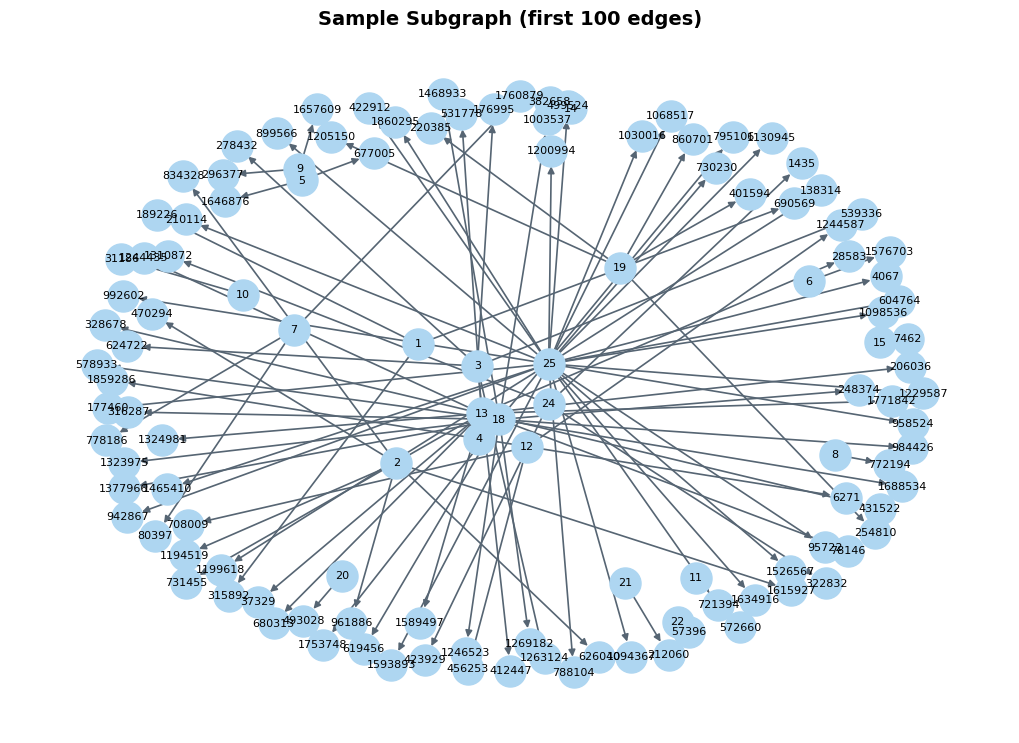

In [6]:
# Visualise a small subgraph (first 100 rows)
pd.read_csv('data/train.csv', nrows=100).to_csv(
    'data/train_sample_100.csv', index=False, header=False
)
subgraph = nx.read_edgelist(
    'data/train_sample_100.csv', delimiter=',',
    create_using=nx.DiGraph(), nodetype=int
)

print(f'Subgraph — Nodes: {subgraph.number_of_nodes()}, Edges: {subgraph.number_of_edges()}')

pos = nx.spring_layout(subgraph, seed=42)
plt.figure(figsize=(10, 7))
nx.draw(
    subgraph, pos, with_labels=True,
    node_color='#AED6F1', edge_color='#566573',
    node_size=500, font_size=8, width=1.2, arrows=True
)
plt.title('Sample Subgraph (first 100 edges)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 4. Degree Distribution Analysis

### 4a. Followers (in-degree)

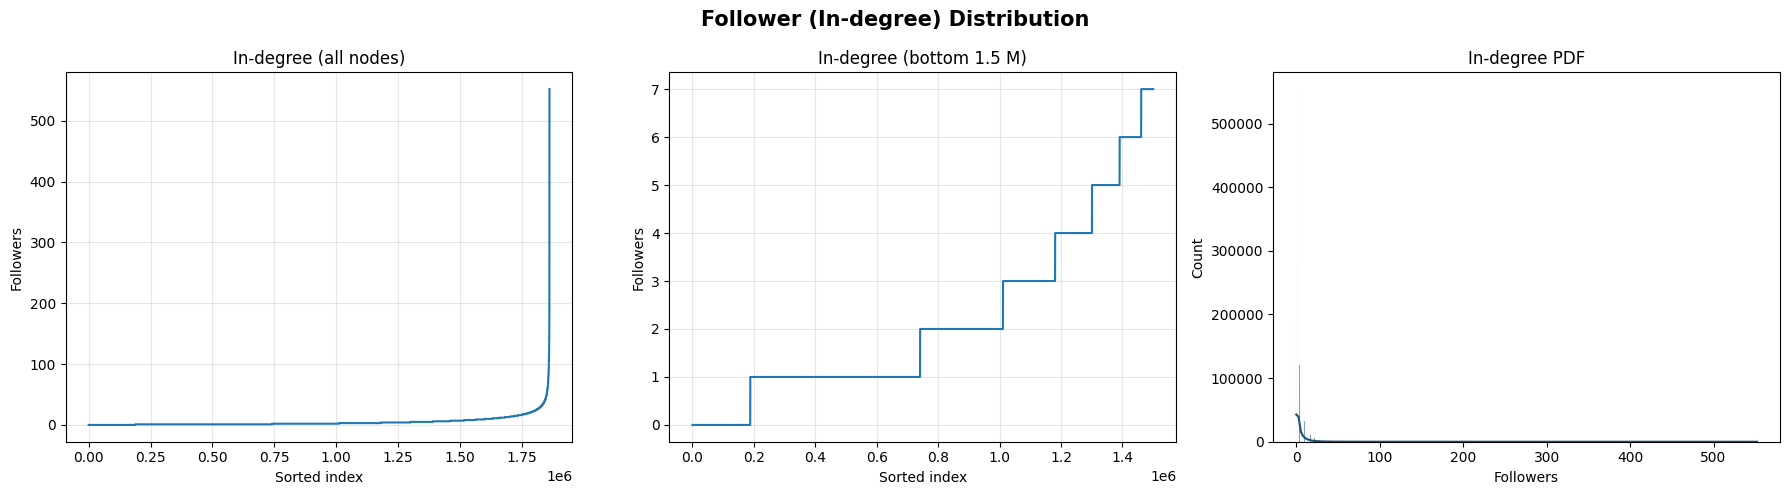

In-degree percentiles:
   90.0th : 12
   91.0th : 13
   92.0th : 14
   93.0th : 15
   94.0th : 17
   95.0th : 19
   96.0th : 21
   97.0th : 24
   98.0th : 29
   99.0th : 40
  100.0th : 552
   99.1th : 42
   99.3th : 47
   99.5th : 55
   99.7th : 70
   99.9th : 112


In [7]:
indegree_dist = sorted(dict(graph.in_degree()).values())

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].plot(indegree_dist)
axes[0].set(title='In-degree (all nodes)', xlabel='Sorted index', ylabel='Followers')
axes[0].grid(alpha=0.3)

axes[1].plot(indegree_dist[:1_500_000])
axes[1].set(title='In-degree (bottom 1.5 M)', xlabel='Sorted index', ylabel='Followers')
axes[1].grid(alpha=0.3)

sns.histplot(indegree_dist, kde=True, color='#1A5276', ax=axes[2])
axes[2].set(title='In-degree PDF', xlabel='Followers')

plt.suptitle('Follower (In-degree) Distribution', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

print('In-degree percentiles:')
for p in list(range(90, 101)) + [99.1, 99.3, 99.5, 99.7, 99.9]:
    print(f'  {p:5.1f}th : {np.percentile(indegree_dist, p):.0f}')

### 4b. Following (out-degree)

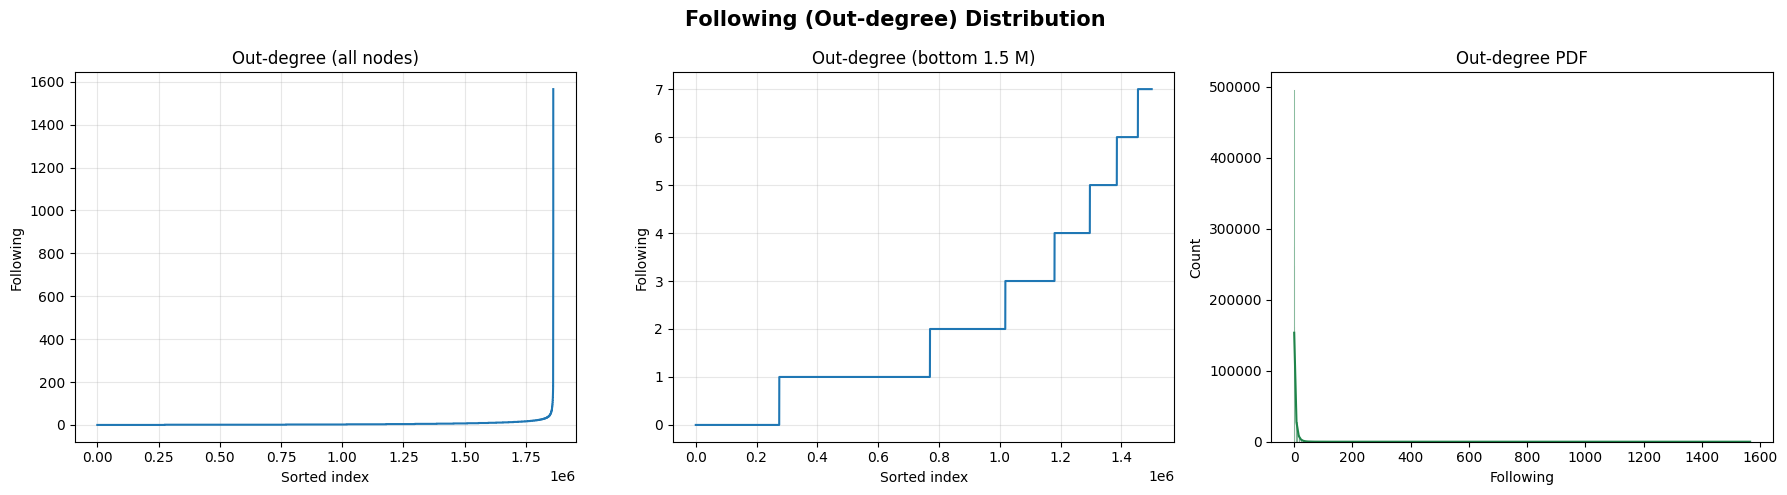

Out-degree percentiles (90–100):
  90th : 12
  91th : 13
  92th : 14
  93th : 15
  94th : 17
  95th : 19
  96th : 21
  97th : 24
  98th : 29
  99th : 40
  100th : 1566


In [8]:
outdegree_dist = sorted(dict(graph.out_degree()).values())

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].plot(outdegree_dist)
axes[0].set(title='Out-degree (all nodes)', xlabel='Sorted index', ylabel='Following')
axes[0].grid(alpha=0.3)

axes[1].plot(outdegree_dist[:1_500_000])
axes[1].set(title='Out-degree (bottom 1.5 M)', xlabel='Sorted index', ylabel='Following')
axes[1].grid(alpha=0.3)

sns.histplot(outdegree_dist, kde=True, color='#1E8449', ax=axes[2])
axes[2].set(title='Out-degree PDF', xlabel='Following')

plt.suptitle('Following (Out-degree) Distribution', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

print('Out-degree percentiles (90–100):')
for p in range(90, 101):
    print(f'  {p}th : {np.percentile(outdegree_dist, p):.0f}')

### 4c. Combined (in + out degree)

Max  in+out : 1,579  (shared by 1 nodes)
Min  in+out : 1  (shared by 334,291 nodes)
Nodes with in+out < 10 : 1,320,326


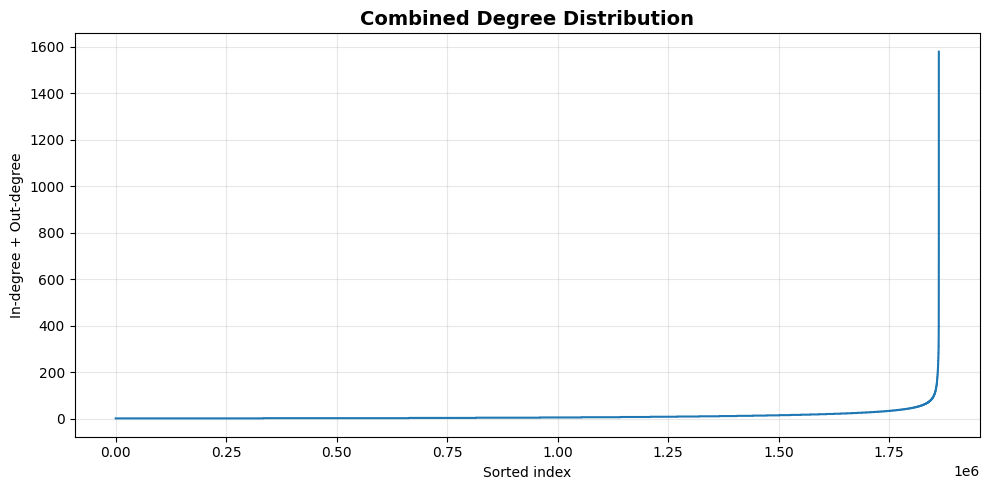

CPU times: total: 6.42 s
Wall time: 8.52 s


In [9]:
%%time

dict_in  = dict(graph.in_degree())
dict_out = dict(graph.out_degree())
combined = Counter(dict_in) + Counter(dict_out)
in_out   = np.array(list(combined.values()))
in_out_sorted = sorted(in_out)

print(f'Max  in+out : {in_out.max():,}  '
      f'(shared by {np.sum(in_out == in_out.max()):,} nodes)')
print(f'Min  in+out : {in_out.min():,}  '
      f'(shared by {np.sum(in_out == in_out.min()):,} nodes)')
print(f'Nodes with in+out < 10 : {np.sum(in_out < 10):,}')

plt.figure(figsize=(10, 5))
plt.plot(in_out_sorted)
plt.xlabel('Sorted index')
plt.ylabel('In-degree + Out-degree')
plt.title('Combined Degree Distribution', fontsize=14, fontweight='bold')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### 4d. Isolated node counts

In [10]:
n_no_following = sum(1 for v in outdegree_dist if v == 0)
n_no_followers = sum(1 for v in indegree_dist if v == 0)
n_total        = graph.number_of_nodes()

print(f'Nodes following nobody   : {n_no_following:,}  ({n_no_following/n_total*100:.2f}%)')
print(f'Nodes with zero followers : {n_no_followers:,}  ({n_no_followers/n_total*100:.2f}%)')

# Fully isolated (no edges at all)
isolated = sum(
    1 for node in graph.nodes()
    if graph.in_degree(node) == 0 and graph.out_degree(node) == 0
)
print(f'Fully isolated nodes      : {isolated:,}')

Nodes following nobody   : 274,512  (14.74%)
Nodes with zero followers : 188,043  (10.10%)
Fully isolated nodes      : 0


## 5. Connected Components

In [11]:
%%time

wcc = list(nx.weakly_connected_components(graph))
print(f'Weakly connected components      : {len(wcc):,}')
print(f'WCCs with exactly 2 nodes        : {sum(1 for c in wcc if len(c)==2):,}')
print(f'Largest WCC size                 : {max(len(c) for c in wcc):,}')

Weakly connected components      : 45,558
WCCs with exactly 2 nodes        : 32,195
Largest WCC size                 : 1,739,520
CPU times: total: 11.1 s
Wall time: 14.4 s


## 6. Negative Edge Sampling

We generate the same number of random *missing* edges as there are positive edges, ensuring perfect class balance. `random.seed(42)` guarantees reproducibility.

In [12]:
%%time

random.seed(42)

TARGET_SIZE = graph.number_of_edges()      # match positive count exactly
MAX_NODE_ID = max(graph.nodes())

missing_edges = set()
while len(missing_edges) < TARGET_SIZE:
    a = random.randint(1, MAX_NODE_ID)
    b = random.randint(1, MAX_NODE_ID)
    if a == b or graph.has_edge(a, b):
        continue
    missing_edges.add((a, b))

with open('data/missing_edges.pkl', 'wb') as f:
    pickle.dump(missing_edges, f)

print(f' Generated {len(missing_edges):,} negative edges.')

 Generated 9,437,519 negative edges.
CPU times: total: 32 s
Wall time: 36.9 s


## 7. Train / Test Split & Save

In [13]:
df_pos = pd.read_csv('data/train.csv')
df_neg = pd.DataFrame(list(missing_edges), columns=['source_node', 'destination_node'])

print(f'Positive edges : {df_pos.shape[0]:,}')
print(f'Negative edges : {df_neg.shape[0]:,}')

Positive edges : 9,437,519
Negative edges : 9,437,519


In [14]:
# 80/20 split — same random_state for reproducibility
X_train_pos, X_test_pos = train_test_split(df_pos, test_size=0.2, random_state=42)
X_train_neg, X_test_neg = train_test_split(df_neg, test_size=0.2, random_state=42)

print(f'Train pos : {X_train_pos.shape[0]:,}   Test pos : {X_test_pos.shape[0]:,}')
print(f'Train neg : {X_train_neg.shape[0]:,}   Test neg : {X_test_neg.shape[0]:,}')

Train pos : 7,550,015   Test pos : 1,887,504
Train neg : 7,550,015   Test neg : 1,887,504


In [15]:
# Save without header/index for nx.read_edgelist compatibility
for df, fname in [
    (X_train_pos, 'data/X_train_pos.csv'),
    (X_train_neg, 'data/X_train_neg.csv'),
    (X_test_pos,  'data/X_test_pos.csv'),
    (X_test_neg,  'data/X_test_neg.csv'),
]:
    df.to_csv(fname, index=False, header=False)

print(' Train/test splits saved to data/')
print('   Files:', os.listdir('data'))

 Train/test splits saved to data/
   Files: ['artifacts.pkl', 'best_model.pkl', 'df_final_test_features.csv', 'df_final_train_features.csv', 'feature_cols.pkl', 'feature_importances.png', 'graph.pkl', 'missing_edges.pkl', 'model_comparison.png', 'model_decision_tree.pkl', 'model_extra_trees.pkl', 'model_gradient_boosting.pkl', 'model_knn.pkl', 'model_lightgbm.pkl', 'model_logistic_regression.pkl', 'model_random_forest.pkl', 'model_tuned_xgboost.pkl', 'model_xgboost.pkl', 'predictor.pkl', 'roc_and_cm_baseline.png', 'roc_comparison_tuned.png', 'train.csv', 'train_no_header.csv', 'train_sample_100.csv', 'wcc.pkl', 'X_test_neg.csv', 'X_test_pos.csv', 'X_train_neg.csv', 'X_train_pos.csv']


In [16]:
%%time

train_graph = nx.read_edgelist(
    'data/X_train_pos.csv', delimiter=',',
    create_using=nx.DiGraph(), nodetype=int
)
test_graph = nx.read_edgelist(
    'data/X_test_pos.csv', delimiter=',',
    create_using=nx.DiGraph(), nodetype=int
)

print(f'Train graph — Nodes: {train_graph.number_of_nodes():,}, Edges: {train_graph.number_of_edges():,}')
print(f'Test  graph — Nodes: {test_graph.number_of_nodes():,},  Edges: {test_graph.number_of_edges():,}')


Train graph — Nodes: 1,780,564, Edges: 7,550,015
Test  graph — Nodes: 1,145,880,  Edges: 1,887,504
CPU times: total: 1min 7s
Wall time: 1min 9s
